### Gráficos estacionales

Es un gráfico que horizontalmente representa un periodo de tiempo (meses, años, días) en lugar de instantes de tiempo y en el eje vertical se grafican múltiples periodos de tiempo

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

In [24]:
co2 = pd.read_csv('datos/co2.csv',
                parse_dates=['fecha'],
                index_col='fecha')
co2

,co2
fecha,
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4
...,...
2001-12-01,370.3
2001-12-08,370.8
2001-12-15,371.2


<Axes: xlabel='fecha'>

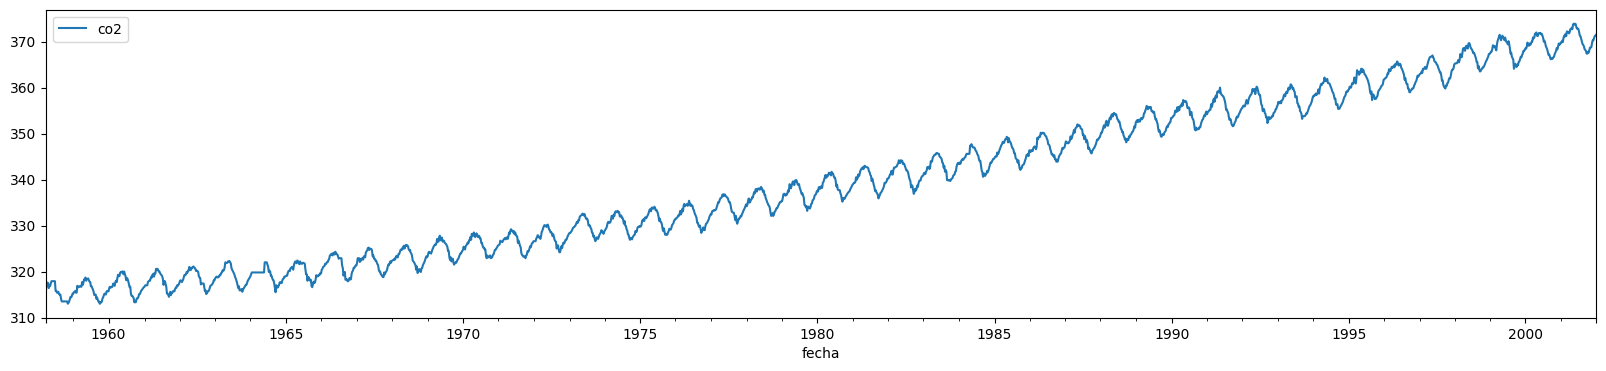

In [25]:
co2.plot(figsize=(20,4))

In [26]:
co2.index # Muestreos semanales

DatetimeIndex(['1958-03-29', '1958-04-05', '1958-04-12', '1958-04-19',
               '1958-04-26', '1958-05-03', '1958-05-10', '1958-05-17',
               '1958-05-24', '1958-05-31',
               ...
               '2001-10-27', '2001-11-03', '2001-11-10', '2001-11-17',
               '2001-11-24', '2001-12-01', '2001-12-08', '2001-12-15',
               '2001-12-22', '2001-12-29'],
              dtype='datetime64[us]', name='fecha', length=2284, freq=None)

In [29]:
co2_M = co2.resample('ME').sum()

In [30]:
co2_M['Mes'] = co2_M.index.month
co2_M['Año'] = co2_M.index.year

co2_M

,co2,Mes,Año
fecha,,,
1958-03-31,316.1,3,1958
1958-04-30,1268.8,4,1958
1958-05-31,1587.1,5,1958
1958-06-30,1271.6,6,1958
1958-07-31,1262.5,7,1958
...,...,...,...
2001-08-31,1477.7,8,2001
2001-09-30,1839.4,9,2001
2001-10-31,1472.2,10,2001


In [32]:
co2_M_pivote = co2_M.pivot(index='Mes', columns='Año', values='co2')
co2_M_pivote

Año,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,...,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001
Mes,,,,,,,,,,,,,,,,,,,,,
1,NaN,1577.5,1581.9,1267.7,1271.7,1274.9,1278.0,1597.0,1602.7,1290.6,...,1423.6,1783.4,1791.6,1439.9,1448.1,1452.5,1826.7,1840.6,1845.1,1480.7
2,NaN,1265.5,1267.9,1270.6,1274.5,1275.8,1599.0,1281.8,1286.3,1289.7,...,1783.4,1428.7,1435.6,1443.7,1452.7,1455.5,1464.8,1475.4,1477.5,1485.3
3,316.1,1267.0,1270.3,1274.1,1598.4,1599.3,1279.2,1283.7,1289.5,1292.0,...,1431.6,1433.7,1439.7,1446.3,1820.3,1822.8,1469.5,1478.4,1481.6,1860.3
4,1268.8,1270.7,1595.6,1597.1,1282.2,1285.1,1279.2,1288.0,1618.3,1621.4,...,1436.3,1437.3,1806.1,1816.8,1458.8,1465.3,1474.1,1483.9,1857.7,1491.1
5,1587.1,1591.7,1279.7,1281.9,1283.6,1288.2,1601.2,1610.3,1296.1,1299.8,...,1797.7,1800.9,1446.6,1454.8,1461.3,1833.4,1845.7,1854.2,1486.6,1495.2
6,1271.6,1272.1,1277.8,1279.0,1602.5,1607.3,1287.5,1287.1,1294.8,1296.3,...,1436.5,1438.0,1443.6,1453.0,1824.4,1461.9,1475.0,1481.0,1486.5,1865.3
7,1262.5,1266.1,1590.3,1591.6,1277.7,1278.4,1281.2,1605.2,1614.4,1612.4,...,1428.0,1787.1,1797.3,1809.0,1453.9,1457.5,1470.4,1845.0,1849.7,1485.2
8,1574.8,1574.5,1263.1,1267.1,1270.6,1588.0,1593.1,1274.9,1280.8,1283.4,...,1774.3,1421.3,1429.5,1437.5,1806.6,1812.3,1828.6,1466.8,1471.8,1477.7
9,1254.0,1255.3,1256.7,1575.2,1583.0,1264.6,1266.4,1271.3,1274.8,1596.5,...,1412.1,1415.1,1423.7,1790.0,1437.6,1440.6,1455.7,1458.7,1832.7,1839.4


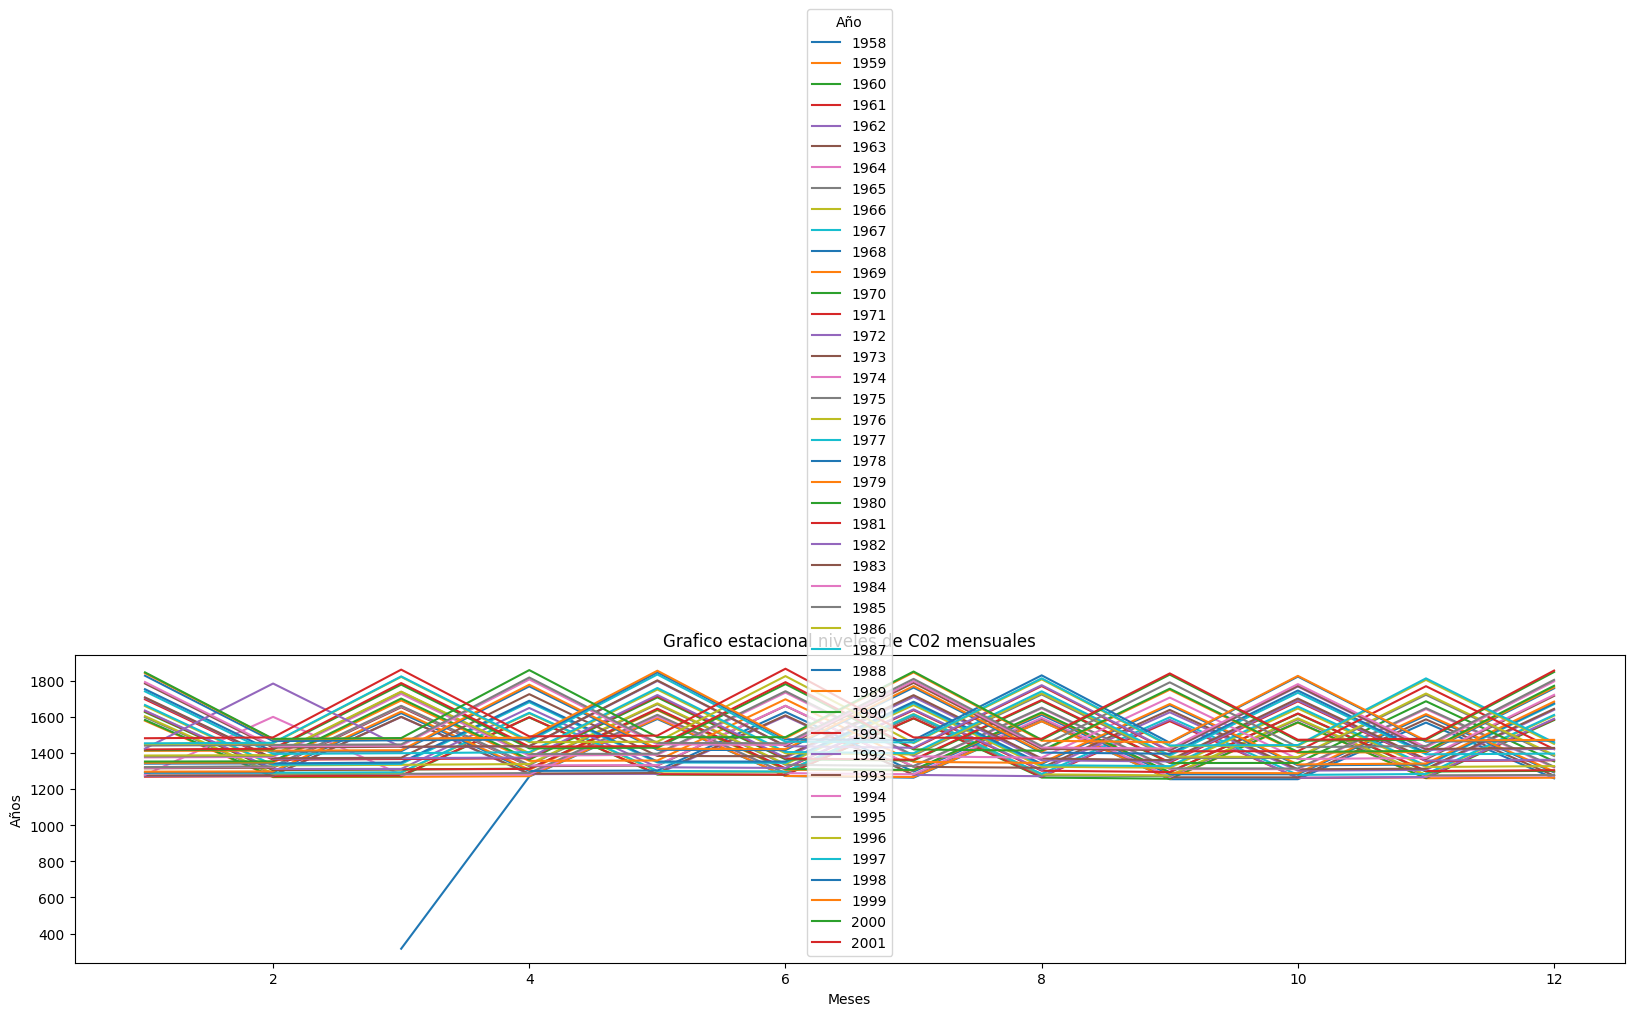

In [ ]:
co2_M_pivote.plot(figsize=(20,4))
plt.title('Grafico estacional niveles de C02 mensuales')
plt.xlabel('Meses')
plt.ylabel('Años')
plt.legend(title = 'Año')
plt.show()

# No solamente se aprecia la estacionalidad, también se encuentra la tendencia

In [ ]:
co2_STL = STL(co2['co2'], 
            seasonal = 13).fit()

co2_STL_seasonal = co2_STL.seasonal.to_frame('co2')
co2_STL_seasonal
# Este es el componenete estacional con una frecuencia semanal

,co2
fecha,
1958-03-29,1.011757
1958-04-05,2.071207
1958-04-12,2.094911
1958-04-19,2.040090
1958-04-26,1.928559
...,...
2001-12-01,-1.122142
2001-12-08,-0.607338
2001-12-15,-0.528068


In [60]:
co2_STL_seasonal_M = co2_STL_seasonal.resample('ME').sum()

co2_STL_seasonal_M['Mes'] = co2_STL_seasonal_M.index.month
co2_STL_seasonal_M['Año'] = co2_STL_seasonal_M.index.year

co2_STL_seasonal_M_p = co2_STL_seasonal_M.pivot(index = 'Mes', columns = 'Año', values = 'co2')
co2_STL_seasonal_M_p

Año,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,...,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001
Mes,,,,,,,,,,,,,,,,,,,,,
1,NaN,-1.089176,-1.011645,-0.340322,-0.274794,-0.216983,-0.154676,0.281169,0.290606,0.676414,...,0.175438,0.355298,0.281522,0.545668,0.539332,0.456663,0.918917,0.865853,0.814779,0.922222
2,NaN,1.805297,1.852096,1.897776,1.936005,1.961324,2.744181,2.444692,2.365770,2.306301,...,3.799312,3.369603,3.254192,3.168701,3.163284,3.175144,3.765379,3.634439,3.488566,3.330695
3,1.011757,4.135871,4.139701,4.137057,5.839351,5.763640,4.918727,4.810914,4.766269,4.765877,...,6.759340,6.720638,6.553877,6.253091,8.404441,8.077911,6.620876,6.392615,6.173735,8.074356
4,8.134767,8.023172,10.106518,10.012874,8.240623,8.272251,8.251183,8.214564,10.623642,10.662701,...,10.952911,10.856965,13.932130,13.760133,11.066052,10.779831,10.492374,10.213481,12.376001,9.881191
5,12.952665,12.759668,10.370968,10.198058,10.064852,9.966651,12.563723,12.484045,10.060974,10.156952,...,16.059519,16.078186,12.778482,12.552764,12.195786,14.643721,14.323167,14.008168,11.255390,11.046895
6,9.441674,9.512540,9.581991,9.647247,11.183150,11.399397,8.844107,8.961844,9.042210,9.054678,...,9.358869,9.587662,9.756056,9.784035,11.363902,8.669265,8.768530,8.872454,8.983355,10.721190
7,2.163825,2.743828,3.407924,4.048705,3.194199,3.632590,3.989124,4.306767,4.602912,4.873872,...,2.711148,2.489351,2.953547,3.519069,2.423023,2.821821,3.208097,3.074235,3.510753,2.308314
8,-4.288380,-4.075894,-3.963356,-3.842250,-3.720409,-5.451452,-5.207822,-5.030042,-4.777794,-4.480830,...,-7.882146,-6.921753,-6.469768,-6.006336,-8.355316,-7.926675,-7.485388,-6.534472,-6.177633,-5.831801
9,-9.485942,-9.513045,-9.528864,-12.335706,-12.440193,-10.658262,-10.661109,-10.556364,-10.484731,-13.738595,...,-13.639625,-13.490901,-13.316762,-16.911985,-13.960118,-13.776780,-13.605334,-13.438434,-16.906722,-16.735983


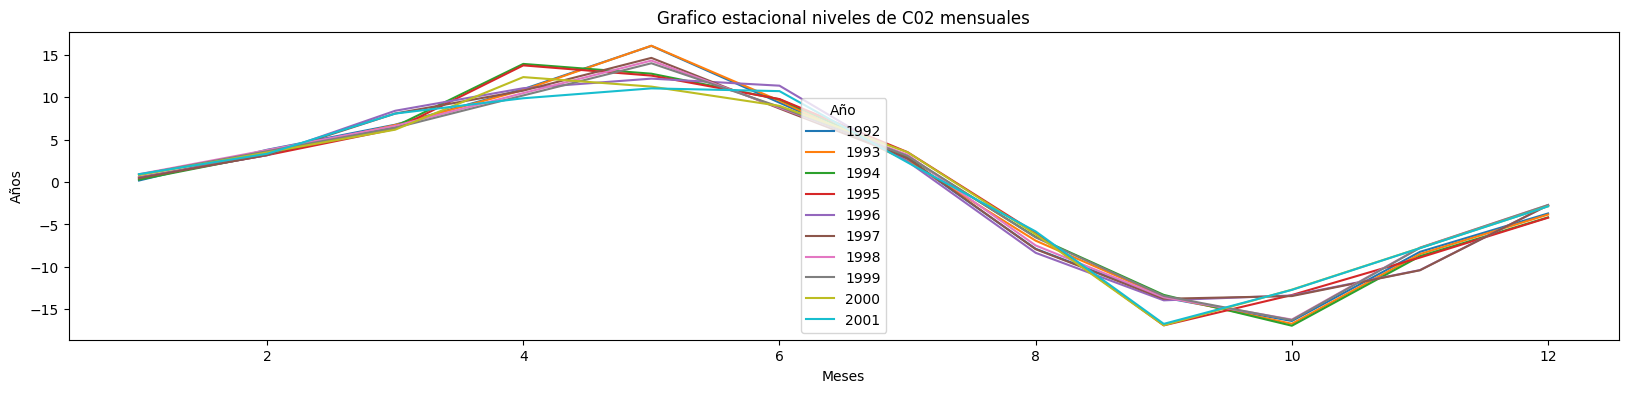

In [64]:
co2_STL_seasonal_M_p.iloc[:,-10:].plot(figsize=(20,4))
plt.title('Grafico estacional niveles de C02 mensuales')
plt.xlabel('Meses')
plt.ylabel('Años')
plt.legend(title = 'Año')
plt.show()